In [1]:
from MCEq.core import MCEqRun
import crflux.models as pm
import xarray as xr
import re
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.colors as colors
import colorcet as cc
import pickle as p
import matplotlib as mpl

In [2]:
era5_dataset = xr.load_dataset("/home/leoseen/aos_773/final_project/era5_reanalysis_2025.grib", engine = 'cfgrib')
spole_data = era5_dataset.t.sel(latitude = '-90', longitude = '-180.0')
spole_daily_data = spole_data.groupby('time.date')

In [3]:
for _, data in spole_daily_data:
    day = data.time.values.astype('datetime64[D]').astype(object)[0].day
    if day == 17:
        constant_strat = data[0][4:]

In [4]:
geopotential_dataset = xr.load_dataset("/home/leoseen/aos_773/final_project/geopotential.grib", engine = 'cfgrib')
geopotential_data = geopotential_dataset.sel(latitude = '-90', longitude = '-180.0')
g = 9.8
R = 6378388
geom_height = R*geopotential_data.z/(g*R-geopotential_data.z)
geom_daily_data = geom_height.groupby('time.date')

In [5]:
def calculate_density_from_temperature(temperature_data):
    density_data = temperature_data.isobaricInhPa.values*1e2*28.9647/(8.314*(temperature_data.values)*1e6)
    return density_data

def get_one_solver(height_data, temperature_data):
    density_data = calculate_density_from_temperature(temperature_data)
    length = np.max(height_data.values)-np.min(height_data.values)
    traverse_length = (np.max(height_data.values) - height_data.values)*1e2

    mceq_run = MCEqRun(
            interaction_model='SIBYLL2.3e',
            primary_model = (pm.HillasGaisser2012, "H4a"),
            theta_deg=0.0,
            density_model = ('GeneralizedTarget', None)
            )
    mceq_run.density_model.set_length(length*1e2)
    for tl, rho in zip(np.flip(traverse_length)[:-1], np.flip(density_data)[:-1]):
        mceq_run.density_model.add_material(tl, rho, 'air')
    mceq_run.solve()
    return mceq_run

In [6]:
bl_effects = False
# For some reason, running entire loop crashes notebook, so have to run one hour at a time. 
for (day_1, h_daily_data), (day_2, temp_daily_data) in zip(geom_daily_data, spole_daily_data):
    for h_data, temp_data in zip(h_daily_data, temp_daily_data):
        if h_data.time.values.astype('datetime64[D]').astype(object).day == temp_data.time.values.astype('datetime64[D]').astype(object).day == 17:
            hour_1 = h_data.time.values.astype('datetime64[h]').astype(object).hour
            hour_2 = temp_data.time.values.astype('datetime64[h]').astype(object).hour
            if hour_1 == hour_2 == 0:
                if not temp_data.time.values == h_data.time.values:
                    print('Not the same day')
                if not np.array_equal(temp_data.isobaricInhPa.values,h_data.isobaricInhPa.values):
                    print('Not same pressure')
                if bl_effects:
                    temp_data.values[4:] = constant_strat
                print(temp_data.values)
                mceq_run = get_one_solver(h_data, temp_data)
                mu_conv = mceq_run.get_solution('conv_mu+', 3)+ mceq_run.get_solution('conv_mu-', 3)
                # np.save(f'/home/leoseen/aos_773/final_project/mceq_runs_saves/bl_variations/conv_mu_{hour_1}.npy',mu_conv)

[247.27696 246.07915 244.86589 243.6484  242.35081 241.09172 239.7427
 238.42726 237.00357 235.54024 234.03021 231.10934 232.57637 237.64737
 236.90573 233.17937 229.32076 224.27898 218.93565 213.08981 205.48332
 201.56657 199.08604 197.70201 196.47969 194.83075 192.7402  191.19571
 190.62418 193.49884 199.96796 217.25412 229.51256 242.76811 260.35526
 271.68445 279.5418 ]
MCEqRun::set_interaction_model(): SIBYLL23E
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, np.int64(0))).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, np.int64(0))).
MCEqRun::set_density_model(): Setting density profile to GeneralizedTarget None
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H4a)


[]

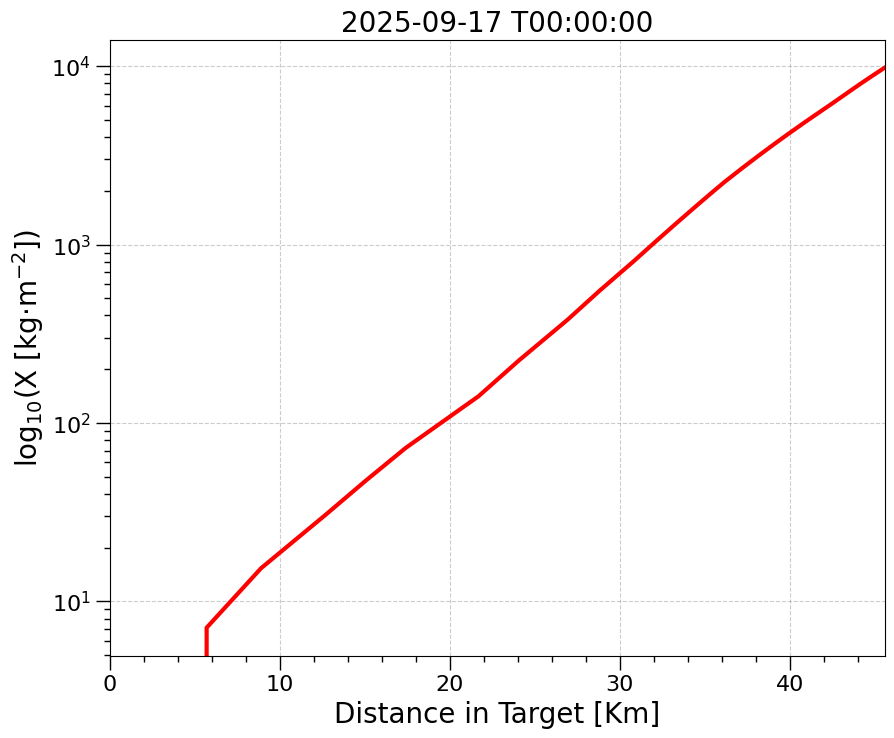

In [46]:
fig, ax = plt.subplots(1,1,figsize = (10,8))
ax.plot([xl/1e5 for xl in mceq_run.density_model.knots], np.array(mceq_run.density_model.X_int)*10, lw=3, color="r")
ax.set_xlim(0,mceq_run.density_model.len_target/1e5)
ax.tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax.set_xlabel('Distance in Target [Km]', fontsize = 20)
ax.set_ylabel(r'log$_{10}$(X [kg$\cdot$m$^{-2}$])', fontsize = 20)
ax.grid(color = 'grey', linestyle = '--', alpha = 0.4)
ax.xaxis.set_minor_locator(MultipleLocator(2))
ax.set_title('2025-09-17 T00:00:00', fontsize = 20)
ax.semilogy()
# mceq_run.density_model.draw_materials(ax)

In [13]:
def get_location_number(path):
    match = re.search(r'conv_mu_(\d+)', path)
    return int(match.group(1)) if match else None

In [ ]:
save_files = glob.glob('/home/leoseen/aos_773/final_project/mceq_runs_saves/full_profile/*.npy')
sorted_files = sorted(save_files, key=get_location_number)
conv_mu_datas = []
for sorted_file in sorted_files:
    conv_mu_datas.append(np.load(sorted_file))


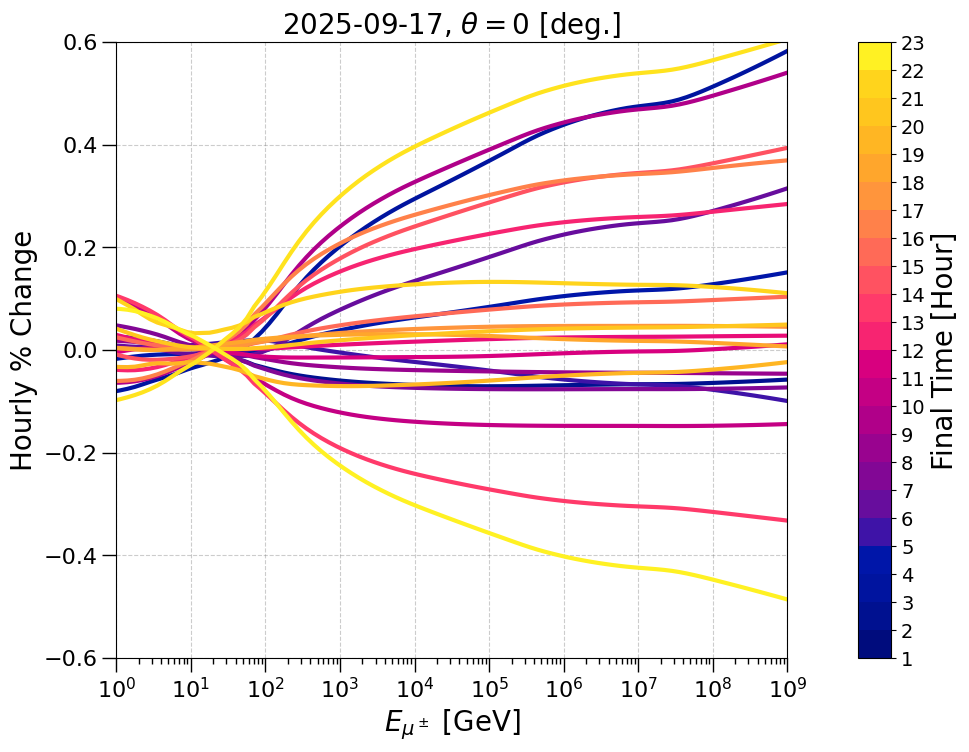

In [9]:
fig, axs = plt.subplots(1,2,figsize = (10,8), gridspec_kw={'width_ratios': [20, 1]})
cmap = plt.get_cmap('cet_bmy')
colors_to_plot = cmap(np.linspace(0,1,24))
    
for i in range(len(conv_mu_datas)-1):
    axs[0].plot(mceq_run.e_grid, 100*((conv_mu_datas[i+1]/conv_mu_datas[i])-1), color = colors_to_plot[i+1], linewidth = 3)

cmap = mpl.colors.ListedColormap(colors_to_plot)
norm = mpl.colors.BoundaryNorm(np.arange(1,24,1), cmap.N)
cb = mpl.colorbar.ColorbarBase(axs[1], norm = norm, cmap=cmap,
                               orientation = 'vertical',ticks = np.arange(1,24,1),spacing = 'uniform')
cb.ax.tick_params(labelsize=14)
cb.set_label('Final Time [Hour]', fontsize = 20)
axs[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
axs[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
axs[0].set_xlabel(r'$E_{\mu^\pm}$ [GeV]', fontsize = 20)
axs[0].set_ylabel(r'Hourly % Change', fontsize = 20)
axs[0].semilogx()
axs[0].set_title(r'2025-09-17, $\theta = 0$ [deg.]', fontsize = 20)
axs[0].set_xlim(1, 1e9)
axs[0].set_ylim(-0.6, 0.6)
axs[0].grid(color = 'grey', alpha = 0.4, linestyle = '--')

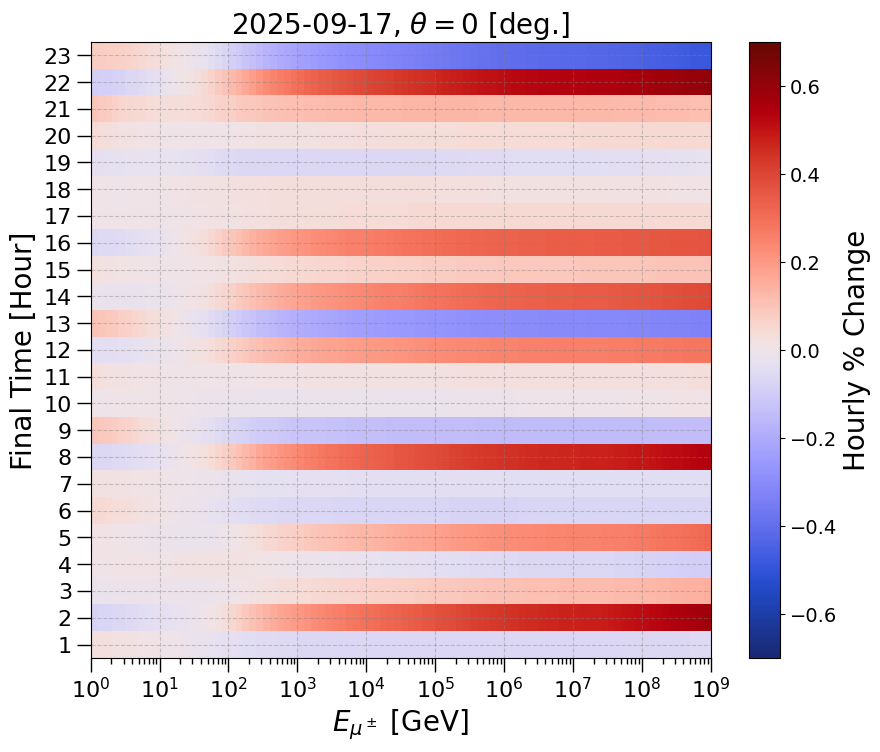

In [15]:
fig, axs = plt.subplots(1,1,figsize = (10,8))

pdiff = 100 * ((np.array(conv_mu_datas[1:]) / np.array(conv_mu_datas[:-1])) - 1)
norm = colors.TwoSlopeNorm(0, vmin = -0.7, vmax = 0.7)
cm = axs.pcolormesh(mceq_run.e_grid, np.arange(1,24,1), pdiff, shading = 'auto', norm = norm, cmap = cc.cm.CET_D1A)# , vmin = -0.6, vmax = 0.6)

cbar = plt.colorbar(cm)
cbar.ax.tick_params(labelsize=14)
cbar.set_label(r'Hourly % Change', fontsize = 20)

axs.tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
axs.tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
axs.set_xlabel(r'$E_{\mu^\pm}$ [GeV]', fontsize = 20)
axs.set_ylabel(r'Final Time [Hour]', fontsize = 20)
axs.semilogx()
axs.set_title(r'2025-09-17, $\theta = 0$ [deg.]', fontsize = 20)
axs.set_xlim(1, 1e9)
axs.set_ylim(0.5, 23.5)
axs.yaxis.set_major_locator(MultipleLocator(1))
axs.grid(color = 'grey', alpha = 0.4, linestyle = '--')

In [14]:
save_files = glob.glob('/home/leoseen/aos_773/final_project/mceq_runs_saves/bl_variations/*.npy')
sorted_files = sorted(save_files, key=get_location_number)
conv_mu_datas = []
for sorted_file in sorted_files:
    conv_mu_datas.append(np.load(sorted_file))

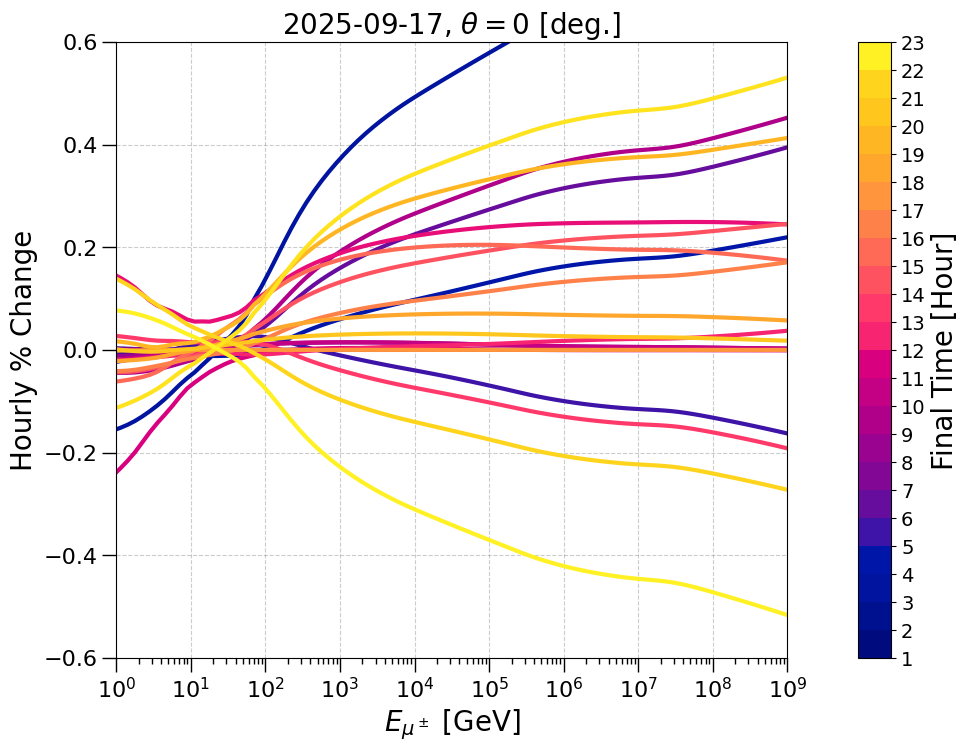

In [19]:
fig, axs = plt.subplots(1,2,figsize = (10,8), gridspec_kw={'width_ratios': [20, 1]})
cmap = plt.get_cmap('cet_bmy')
colors_to_plot = cmap(np.linspace(0,1,24))
    
for i in range(len(conv_mu_datas)-1):
    axs[0].plot(mceq_run.e_grid, 100*((conv_mu_datas[i+1]/conv_mu_datas[i])-1), color = colors_to_plot[i+1], linewidth = 3)

cmap = mpl.colors.ListedColormap(colors_to_plot)
norm = mpl.colors.BoundaryNorm(np.arange(1,24,1), cmap.N)
cb = mpl.colorbar.ColorbarBase(axs[1], norm = norm, cmap=cmap,
                               orientation = 'vertical',ticks = np.arange(1,24,1),spacing = 'uniform')
cb.ax.tick_params(labelsize=14)
cb.set_label('Final Time [Hour]', fontsize = 20)
axs[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
axs[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
axs[0].set_xlabel(r'$E_{\mu^\pm}$ [GeV]', fontsize = 20)
axs[0].set_ylabel(r'Hourly % Change', fontsize = 20)
axs[0].semilogx()
axs[0].set_title(r'2025-09-17, $\theta = 0$ [deg.]', fontsize = 20)
axs[0].set_xlim(1, 1e9)
axs[0].set_ylim(-0.6, 0.6)
axs[0].grid(color = 'grey', alpha = 0.4, linestyle = '--')

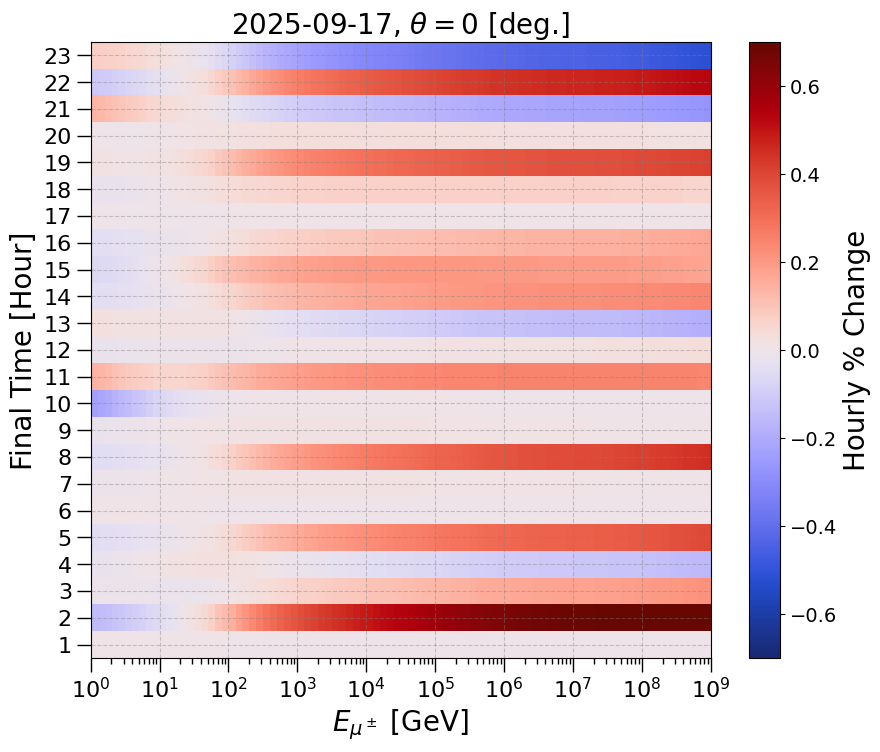

In [15]:
fig, axs = plt.subplots(1,1,figsize = (10,8))

pdiff = 100 * ((np.array(conv_mu_datas[1:]) / np.array(conv_mu_datas[:-1])) - 1)
norm = colors.TwoSlopeNorm(0, vmin = -0.7, vmax = 0.7)
cm = axs.pcolormesh(mceq_run.e_grid, np.arange(1,24,1), pdiff, shading = 'auto', norm = norm, cmap = cc.cm.CET_D1A)# , vmin = -0.6, vmax = 0.6)

cbar = plt.colorbar(cm)
cbar.ax.tick_params(labelsize=14)
cbar.set_label(r'Hourly % Change', fontsize = 20)

axs.tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
axs.tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
axs.set_xlabel(r'$E_{\mu^\pm}$ [GeV]', fontsize = 20)
axs.set_ylabel(r'Final Time [Hour]', fontsize = 20)
axs.semilogx()
axs.set_title(r'2025-09-17, $\theta = 0$ [deg.]', fontsize = 20)
axs.set_xlim(1, 1e9)
axs.set_ylim(0.5, 23.5)
axs.yaxis.set_major_locator(MultipleLocator(1))
axs.grid(color = 'grey', alpha = 0.4, linestyle = '--')